# Phase 1, Step 5 — Cleaning

You have 604,800 rows of 1-second flux and 95 flare labels that cross-check
against it. This step turns raw flux into something a model can consume.

**What Step 5 produces:** one clean dataset with log-transformed flux, gaps
handled honestly, a background estimate, and excess-above-background — plus an
explicit record of which samples are trustworthy.

**What it does NOT do:** build windows or labels. That is Step 6. Cleaning and
labelling are separate because a cleaning bug that hides inside label logic is
almost impossible to find later.

---

### Corrections folded into this version

**1. Quality flags restored.** Notebook 03 kept only `xrsa` and `xrsb` to save
memory. The files are 3.35 MB/day — memory was never the constraint, and the
flags are how NOAA tells you which readings to distrust. Cell 2 reloads
everything; the download is cached, so it is fast.

**2. Background index alignment (§6).** The first version mapped the 1-minute
background back with `.reindex(df.index)`. GOES 1-second timestamps carry a
sub-second offset, so *no* resampled label matched and it silently returned
100% NaN — which then poisoned `excess`, `ratio`, and the whole of §7. Now uses
`ffill` for the causal estimate and `np.interp` for the centred one, with an
`assert` so it can never fail quietly again.

**3. Adaptive threshold (§7).** The flare-end diagnostic hardcoded "flux returns
to within 20% of background". During solar maximum that never happens, so the
loop produced nothing and crashed on an empty DataFrame. It now checks whether
the target is reachable, adapts if not, adds a scale-free e-folding measure, and
counts its own failures instead of throwing.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sunpy.net import Fido, attrs as a
from sunpy.timeseries import TimeSeries

DATA = Path("../data") if Path("../data").exists() else Path("data")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

SOFT, HARD, ACC, BAD = "#c0392b", "#e67e22", "#2c7fb8", "#8e44ad"

TSTART, TEND = "2024-08-01 00:00", "2024-08-08 00:00"
SATELLITE = 16

## 1. Reload with every column

In [25]:
search = Fido.search(
    a.Time(TSTART, TEND), a.Instrument.xrs,
    a.Resolution("flx1s"), a.goes.SatelliteNumber(SATELLITE),
)
files = Fido.fetch(search)                      # cached — should be instant
raw = TimeSeries(files, concatenate=True).to_dataframe()
raw = raw[(raw.index >= TSTART) & (raw.index < TEND)]

print(f"Rows    : {len(raw):,}")
print(f"Columns : {list(raw.columns)}")
print()
print(raw.head(3))

Files Downloaded:   0%|          | 0/8 [00:00<?, ?file/s]

Rows    : 604,800
Columns : ['xrsa', 'xrsb', 'xrsa_quality', 'xrsb_quality', 'xrsa_primary_chan', 'xrsb_primary_chan']

                                    xrsa      xrsb  xrsa_quality  \
2024-08-01 00:00:00.982231  2.514863e-07  0.000007             0   
2024-08-01 00:00:01.982233  2.417933e-07  0.000007             0   
2024-08-01 00:00:02.982234  2.353208e-07  0.000007             0   

                            xrsb_quality  xrsa_primary_chan  xrsb_primary_chan  
2024-08-01 00:00:00.982231             0                  1                  1  
2024-08-01 00:00:01.982233             0                  1                  1  
2024-08-01 00:00:02.982234             0                  1                  1  


## 2. What the quality flags say

NOAA ships per-sample quality flags. **0 conventionally means good**; non-zero
values encode specific problems. A reading can be present and still be
untrustworthy — that is exactly what these catch, and it is the failure mode
`isna()` cannot see.

In [26]:
qcols = [c for c in raw.columns if "quality" in c.lower()]
fcols = [c for c in ["xrsa", "xrsb"] if c in raw.columns]
print("Flux columns   :", fcols)
print("Quality columns:", qcols)
print()

for c in qcols:
    vc = raw[c].value_counts(dropna=False).head(8)
    pct_good = 100 * (raw[c] == 0).sum() / len(raw)
    print(f"{c}:  {pct_good:.2f}% flagged good (0)")
    print(vc.to_string())
    print()

Flux columns   : ['xrsa', 'xrsb']
Quality columns: ['xrsa_quality', 'xrsb_quality']

xrsa_quality:  99.58% flagged good (0)
xrsa_quality
0      602259
409      1322
2         564
137       351
128       270
400        18
256         9
160         6

xrsb_quality:  99.66% flagged good (0)
xrsb_quality
0      602759
409      1322
137       352
128       270
2          64
400        18
256         9
160         6



In [27]:
# Do the flags and the NaNs mark the same samples, or different ones?
for f in fcols:
    q = f + "_quality"
    if q not in raw.columns:
        continue
    nan_n = raw[f].isna().sum()
    badq_n = (raw[q] != 0).sum()
    both = (raw[f].isna() & (raw[q] != 0)).sum()
    print(f"{f}: {nan_n:,} NaN | {badq_n:,} flagged bad | {both:,} are both")
    print(f"      -> {badq_n - both:,} samples have a VALUE but are flagged untrustworthy")
    print()

xrsa: 1,349 NaN | 2,541 flagged bad | 1,349 are both
      -> 1,192 samples have a VALUE but are flagged untrustworthy

xrsb: 1,349 NaN | 2,041 flagged bad | 1,349 are both
      -> 692 samples have a VALUE but are flagged untrustworthy



If that last number is non-zero, those samples would have slipped straight
into your model as real measurements. That is the reason to reload the flags
rather than work from flux alone.

## 3. Gap structure — the distinction that decides the policy

1,349 missing values sounds like one number, but it is really two very different
situations:

- **Scattered single dropouts** — interpolation is fine and loses nothing.
- **Long continuous outages** — interpolating invents a smooth line across
  minutes of missing sky. If a flare started in that gap, you have manufactured
  a flat, flare-free stretch and labelled it as real data.

So count the *runs*, not the samples.

In [28]:
def nan_runs(mask):
    """Lengths and start positions of contiguous True runs in a boolean array."""
    m = np.asarray(mask).astype(np.int8)
    d = np.diff(np.concatenate([[0], m, [0]]))
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0]
    return starts, ends - starts


for f in fcols:
    invalid = raw[f].isna()
    q = f + "_quality"
    if q in raw.columns:
        invalid = invalid | (raw[q] != 0)
    starts, lens = nan_runs(invalid.values)
    if len(lens) == 0:
        print(f"{f}: no invalid samples at all")
        continue
    print(f"{f}: {invalid.sum():,} invalid samples in {len(lens)} run(s)")
    print(f"     run length (seconds): median {np.median(lens):.0f}, "
          f"max {lens.max():.0f}, mean {lens.mean():.1f}")
    print(f"     runs > 60s: {(lens > 60).sum()}   "
          f"runs > 300s: {(lens > 300).sum()}")
    print()

xrsa: 2,541 invalid samples in 850 run(s)
     run length (seconds): median 1, max 1321, mean 3.0
     runs > 60s: 2   runs > 300s: 1

xrsb: 2,041 invalid samples in 351 run(s)
     run length (seconds): median 1, max 1321, mean 5.8
     runs > 60s: 2   runs > 300s: 1



In [29]:
# Where are the long gaps? If one lands inside a flare, you need to know now.
GAP_LIMIT_S = 60          # interpolate runs up to this; mask anything longer

for f in fcols:
    invalid = raw[f].isna()
    q = f + "_quality"
    if q in raw.columns:
        invalid = invalid | (raw[q] != 0)
    starts, lens = nan_runs(invalid.values)
    long_runs = [(raw.index[s], l) for s, l in zip(starts, lens) if l > GAP_LIMIT_S]
    print(f"{f}: {len(long_runs)} run(s) longer than {GAP_LIMIT_S}s")
    for t, l in long_runs[:10]:
        print(f"     {t}  ({l}s = {l/60:.1f} min)")
    print()

xrsa: 2 run(s) longer than 60s
     2024-08-04 05:01:21.755330  (61s = 1.0 min)
     2024-08-04 09:13:55.005500  (1321s = 22.0 min)

xrsb: 2 run(s) longer than 60s
     2024-08-04 05:01:21.755330  (61s = 1.0 min)
     2024-08-04 09:13:55.005500  (1321s = 22.0 min)



## 4. Cleaning policy

Two columns come out of this, and keeping them separate is the whole point:

- `xrsb_clean` — flux with short gaps interpolated
- `xrsb_valid` — **False** wherever the value was invented or untrustworthy

Never silently drop bad rows. A model trained on rows that quietly vanished
learns from a timeline with holes in it. Instead you keep every timestamp and
carry a flag, so Step 6 can decide whether a window containing invented data is
allowed into training.

In [30]:
df = raw[fcols].copy()

for f in fcols:
    invalid = raw[f].isna()
    q = f + "_quality"
    if q in raw.columns:
        invalid = invalid | (raw[q] != 0)

    s = raw[f].where(~invalid)                      # blank out bad values first
    starts, lens = nan_runs(invalid.values)

    # valid = originally good, OR filled across a gap short enough to trust
    valid = ~invalid.values.copy()
    for st, ln in zip(starts, lens):
        if ln <= GAP_LIMIT_S:
            valid[st:st + ln] = True                # short gap: interpolation trusted

    df[f + "_clean"] = s.interpolate(limit=GAP_LIMIT_S, limit_area="inside")
    df[f + "_valid"] = valid & df[f + "_clean"].notna().values

for f in fcols:
    v = df[f + "_valid"]
    print(f"{f}: {v.sum():,} valid ({100*v.mean():.3f}%), "
          f"{(~v).sum():,} unusable")

xrsa: 603,418 valid (99.771%), 1,382 unusable
xrsb: 603,418 valid (99.771%), 1,382 unusable


## 5. Log transform

Flux spans roughly 2.6e-6 to 1.7e-4 in a quiet-to-X-class range — nearly two
orders of magnitude in one week, and more across months. A model reading linear
flux treats one X-class flare as worth more than every other event combined.

**The trap:** `log10(0)` is `-inf` and `log10(negative)` is `nan`. Background-
subtracted or noisy 1-second data can produce both, and a single `-inf` will
poison a whole training batch. Clip to a physical floor first.

In [31]:
FLOOR = 1e-9        # below any real GOES reading; A-class starts at 1e-8

for f in fcols:
    c = df[f + "_clean"]
    n_zero = (c <= 0).sum()
    print(f"{f}: {n_zero} value(s) <= 0 before clipping")
    df["log_" + f] = np.log10(c.clip(lower=FLOOR))

print()
print(df[["log_" + f for f in fcols]].describe().round(3))

xrsa: 0 value(s) <= 0 before clipping
xrsb: 0 value(s) <= 0 before clipping

         log_xrsa    log_xrsb
count  603538.000  603538.000
mean       -6.724      -5.247
std         0.520       0.269
min        -7.735      -5.588
25%        -7.115      -5.434
50%        -6.856      -5.325
75%        -6.459      -5.141
max        -4.268      -3.765


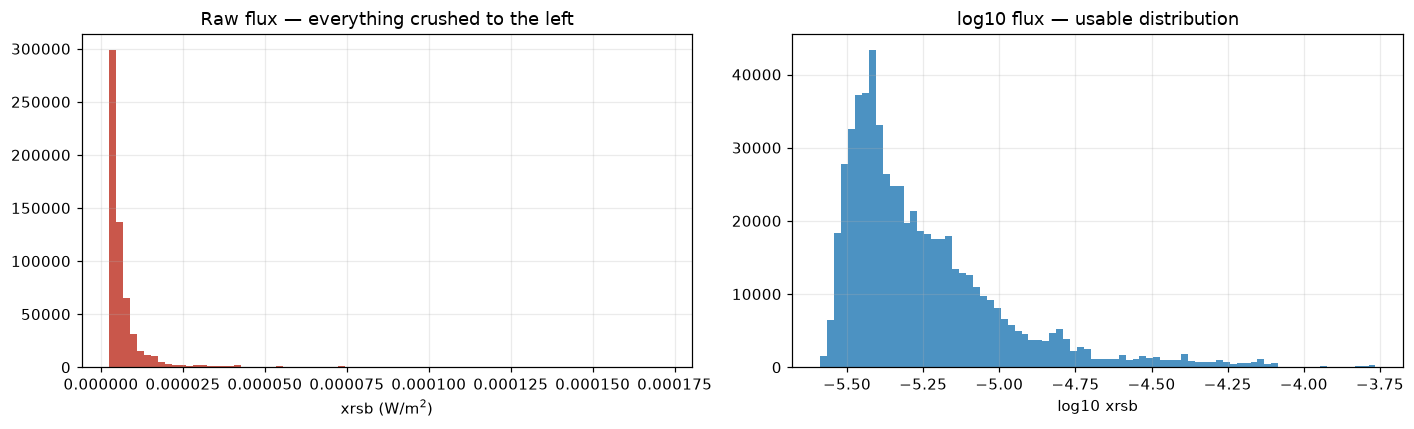

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
v = df["xrsb_valid"]
axes[0].hist(df.loc[v, "xrsb_clean"], bins=80, color=SOFT, alpha=0.85)
axes[0].set_title("Raw flux — everything crushed to the left")
axes[0].set_xlabel("xrsb (W/m$^2$)")
axes[1].hist(df.loc[v, "log_xrsb"], bins=80, color=ACC, alpha=0.85)
axes[1].set_title("log10 flux — usable distribution")
axes[1].set_xlabel("log10 xrsb")
plt.tight_layout()
plt.show()

## 6. Background — and the causality trap

"Is a flare happening?" only means something relative to a background that
drifts over hours and days. Your week sat at a C-class background; a quiet week
sits two decades lower. A fixed threshold cannot work across both.

**The trap that would break your project.** The obvious estimator is a *centred*
rolling quantile — it uses data from both sides, so it is smooth and unbiased.
It is also **impossible in real time**, because half its window is in the future.

Train on centred background, deploy with causal background, and your model meets
inputs at serving time that look nothing like training. That is train/serve
skew, and it usually shows up as a model that scored beautifully and fails live.

So: compute both, compare them, and **use the causal one**.

In [33]:
BG_WINDOW = "4h"      # long enough to sit under a flare, short enough to track drift
BG_Q = 0.05           # 5th percentile ~ the quiet floor

# Rolling quantile on 604,800 rows would be painfully slow, and the background
# varies over hours, so compute it on a 1-minute series and map it back.
minute = df.loc[df["xrsb_valid"], "xrsb_clean"].resample("1min").median()

bg_causal = minute.rolling(BG_WINDOW, min_periods=10).quantile(BG_Q)
bg_centre = minute.rolling(BG_WINDOW, min_periods=10, center=True).quantile(BG_Q)

# ---------------------------------------------------------------------
# Mapping back to the 1-second grid: the step that looks trivial and isn't.
#
# GOES 1-second timestamps carry a sub-second offset (...00:00:00.982231),
# while resample("1min") labels its bins on clean boundaries (...00:00:00).
# NOT ONE label exists in df.index. A plain .reindex(df.index) therefore
# matches nothing and returns 100% NaN -- silently, with no error, because
# "no match" is a normal outcome to pandas and a catastrophe to you.
# ---------------------------------------------------------------------
print("exact index matches:", df.index.isin(minute.index).sum(), "of", len(df))

bc = bg_causal.dropna()
bz = bg_centre.dropna()

# Causal: carry the LAST known value forward. No interpolation toward a future
# sample, so this is exactly what a real-time system would have available.
df["bg_causal"] = bc.reindex(df.index, method="ffill")

# Centred: comparison only, so smooth interpolation is fine.
df["bg_centre"] = np.interp(
    df.index.astype(np.int64), bz.index.astype(np.int64), bz.values
)

# Guard, so this class of bug can never pass silently again.
cov = df["bg_causal"].notna().mean()
warm = df["bg_causal"].isna().sum()
print(f"bg_causal coverage : {100 * cov:.2f}%")
print(f"warm-up rows       : {warm:,}  (~{warm/60:.0f} min at the start of the week)")
assert cov > 0.9, "background is mostly NaN -- index alignment is broken"

diff = (df["bg_causal"] - df["bg_centre"]).abs()
print()
print(f"Median |causal - centred| : {diff.median():.3e} W/m^2")
print(f"As a fraction of background: {100 * (diff / df['bg_centre']).median():.1f}%")

exact index matches: 0 of 604800
bg_causal coverage : 99.91%
warm-up rows       : 540  (~9 min at the start of the week)

Median |causal - centred| : 2.118e-07 W/m^2
As a fraction of background: 5.9%


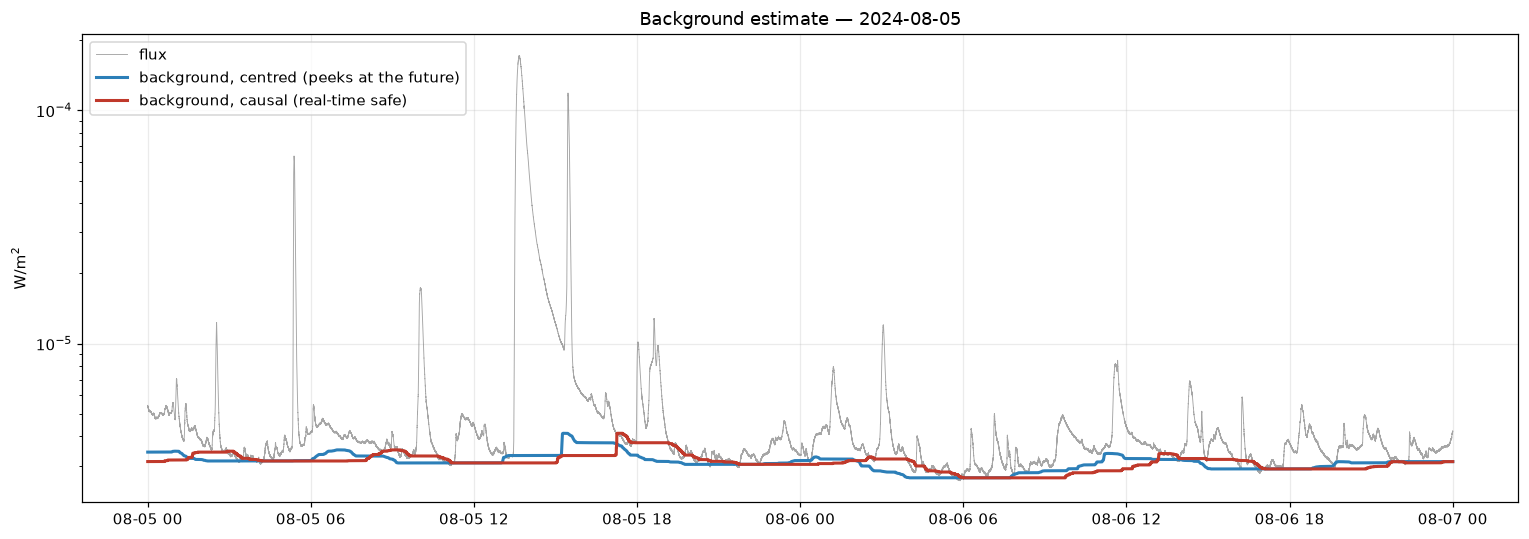

In [34]:
fig, ax = plt.subplots(figsize=(14, 5))
day = slice("2024-08-05", "2024-08-06")
ax.plot(df.loc[day].index, df.loc[day, "xrsb_clean"], lw=0.6, color="gray",
        alpha=0.7, label="flux")
ax.plot(df.loc[day].index, df.loc[day, "bg_centre"], lw=2, color=ACC,
        label="background, centred (peeks at the future)")
ax.plot(df.loc[day].index, df.loc[day, "bg_causal"], lw=2, color=SOFT,
        label="background, causal (real-time safe)")
ax.set_yscale("log")
ax.set_ylabel("W/m$^2$")
ax.set_title("Background estimate — 2024-08-05")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Read the lag.** The causal line should sit slightly to the right of the
centred one, and should stay elevated after a big flare while the centred line
has already come back down. That lag is not a bug — it is the honest cost of not
knowing the future, and your model has to work with it.

In [35]:
# Excess above background: the quantity that actually says "something is happening"
df["excess"] = df["xrsb_clean"] - df["bg_causal"]
df["ratio"] = df["xrsb_clean"] / df["bg_causal"]
df["log_ratio"] = np.log10(df["ratio"].clip(lower=1e-3))

print(df[["excess", "ratio", "log_ratio"]].describe().round(4))

            excess        ratio    log_ratio
count  602998.0000  602998.0000  602998.0000
mean        0.0000       1.8408       0.1634
std         0.0000       2.7110       0.2270
min        -0.0000       0.7601      -0.1191
25%         0.0000       1.0543       0.0229
50%         0.0000       1.2368       0.0923
75%         0.0000       1.5938       0.2024
max         0.0002      55.8526       1.7470


## 7. Diagnostic — when does a flare actually end?

The X1.7 zoom in notebook 01 showed flux still far above background at the
catalogued end time. SWPC's end is an operational definition (roughly the
half-power point), not a return to quiet.

This is a **measurement**, not a decision — Step 6 decides what "flare in
progress" means. But you need the number before you can decide sensibly.

In [36]:
fl = pd.read_parquet(DATA / "flares.parquet")
for c in ["event_starttime", "event_peaktime", "event_endtime"]:
    fl[c] = pd.to_datetime(fl[c])
fl = fl.sort_values("event_starttime").reset_index(drop=True)

# --- Is the target even reachable? Ask the data before assuming. ---
r = df["ratio"].dropna()
print("ratio = flux / causal background")
print(r.describe(percentiles=[.05, .25, .5, .75]).round(3).to_string())
print()
for thr in [1.1, 1.2, 1.5, 2.0]:
    print(f"  week spent at ratio <= {thr}: {100 * (r <= thr).mean():5.1f}%")

RETURN_RATIO = 1.2
if (r <= RETURN_RATIO).mean() < 0.10:
    RETURN_RATIO = round(float(r.quantile(0.20)), 2)
    print(f"\n1.2 is unreachable this week -> using the 20th percentile, {RETURN_RATIO}")
print()

# --- Two measures: one absolute, one scale-free ---
rows, no_seg, no_return = [], 0, 0
for _, f in fl.iterrows():
    seg = df.loc[f["event_peaktime"]: f["event_peaktime"] + pd.Timedelta("6h"), "ratio"].dropna()
    if seg.empty:
        no_seg += 1
        continue

    # (a) time until flux falls back near background
    back = seg[seg <= RETURN_RATIO]
    t_back = (back.index[0] - f["event_peaktime"]).total_seconds() / 60 if len(back) else np.nan
    if np.isnan(t_back):
        no_return += 1

    # (b) e-folding: time for the excess to fall to 1/e of its peak. Always
    #     measurable, and independent of how elevated the background is.
    exc = df.loc[f["event_peaktime"]: f["event_peaktime"] + pd.Timedelta("6h"), "excess"].dropna()
    t_efold = np.nan
    if len(exc) and exc.iloc[0] > 0:
        below = exc[exc <= exc.iloc[0] / np.e]
        if len(below):
            t_efold = (below.index[0] - f["event_peaktime"]).total_seconds() / 60

    rows.append({
        "letter": f["class_letter"],
        "catalogued_min": (f["event_endtime"] - f["event_peaktime"]).total_seconds() / 60,
        "to_background_min": t_back,
        "efold_min": t_efold,
    })

end = pd.DataFrame(rows)
print(f"Flares with usable data : {len(end)} of {len(fl)}")
print(f"  no data in window     : {no_seg}")
print(f"  never returned to bg  : {no_return}")
print()

if end.empty:
    print("No flares measurable -- check that df['ratio'] is not all NaN.")
else:
    print(end.groupby("letter")[["catalogued_min", "to_background_min", "efold_min"]]
             .median().round(1).to_string())
    print()
    for col, name in [("catalogued_min", "catalogued decay"),
                      ("to_background_min", "to background   "),
                      ("efold_min", "e-folding       ")]:
        v = end[col].dropna()
        print(f"Median {name}: {v.median():5.1f} min   (n={len(v)})")
    print()
    print("If the catalogued decay is much shorter than the others, then labelling")
    print("start->catalogued_end marks still-elevated, decaying flux as 'no flare'.")

ratio = flux / causal background
count    602998.000
mean          1.841
std           2.711
min           0.760
5%            0.958
25%           1.054
50%           1.237
75%           1.594
max          55.853

  week spent at ratio <= 1.1:  32.4%
  week spent at ratio <= 1.2:  46.0%
  week spent at ratio <= 1.5:  71.0%
  week spent at ratio <= 2.0:  84.3%

Flares with usable data : 95 of 95
  no data in window     : 0
  never returned to bg  : 0

        catalogued_min  to_background_min  efold_min
letter                                              
C                  7.0               22.7       12.1
M                  5.0               39.8       12.6
X                  9.5              160.5       11.8

Median catalogued decay:   6.0 min   (n=95)
Median to background   :  33.4 min   (n=95)
Median e-folding       :  12.6 min   (n=95)

If the catalogued decay is much shorter than the others, then labelling
start->catalogued_end marks still-elevated, decaying flux as 'no flare'.


## 8. Resampling — store fine, feed coarse

A 30-minute window at 1-second is 1,800 timesteps, which is heavy for an LSTM or
Transformer. At 10 seconds it is 180 — and still resolves the 44-second `xrsa`
lead comfortably.

**Store at full resolution; downsample at model-input time.** Input cadence then
becomes a hyperparameter you tune, not a decision baked into your files.

One subtlety: how you downsample matters. `mean` smooths peaks away; `max`
preserves them but biases the level upward. For flare detection, peak
preservation usually matters more.

In [37]:
def downsample(d, rule, how="max"):
    """Downsample flux columns. 'max' preserves peaks; 'mean' smooths them."""
    cols = [c for c in d.columns if c.endswith("_clean") or c in ("excess", "ratio")]
    agg = {c: how for c in cols}
    out = d[cols].resample(rule).agg(agg)
    # a window is valid only if EVERY sample in it was valid
    for f in fcols:
        vc = f + "_valid"
        if vc in d.columns:
            out[vc] = d[vc].resample(rule).min().astype(bool)
    return out


for rule in ["10s", "30s", "1min"]:
    a_ = downsample(df, rule, "max")
    b_ = downsample(df, rule, "mean")
    pk_a = a_["xrsb_clean"].max()
    pk_b = b_["xrsb_clean"].max()
    print(f"{rule:>5}: {len(a_):>8,} rows | peak(max)={pk_a:.3e} "
          f"peak(mean)={pk_b:.3e} | mean loses {100*(1-pk_b/pk_a):.2f}% of the peak")

  10s:   60,480 rows | peak(max)=1.719e-04 peak(mean)=1.715e-04 | mean loses 0.24% of the peak
  30s:   20,160 rows | peak(max)=1.719e-04 peak(mean)=1.714e-04 | mean loses 0.30% of the peak
 1min:   10,080 rows | peak(max)=1.719e-04 peak(mean)=1.709e-04 | mean loses 0.62% of the peak


## 9. Validate and save

In [38]:
checks = {
    "no NaN in log_xrsb on valid rows": df.loc[df["xrsb_valid"], "log_xrsb"].notna().all(),
    "no infinities":                    not np.isinf(df["log_xrsb"].dropna()).any(),
    "background below flux (median)":   (df["bg_causal"] <= df["xrsb_clean"]).mean() > 0.5,
    "index is sorted":                  df.index.is_monotonic_increasing,
    "no duplicate timestamps":          not df.index.has_duplicates,
    "ratio >= 0":                       (df["ratio"].dropna() >= 0).all(),
    "some rows marked invalid":         (~df["xrsb_valid"]).sum() > 0,
}
for k, v in checks.items():
    print(f"{'PASS' if v else 'FAIL'}  {k}")

if all(checks.values()):
    df.to_parquet(DATA / "goes_clean_1s.parquet")
    print()
    print(f"Saved -> {DATA / 'goes_clean_1s.parquet'}  ({len(df):,} rows, {len(df.columns)} columns)")
    print(list(df.columns))
else:
    print()
    print("Fix the failures before saving — do not build Step 6 on a failed check.")

PASS  no NaN in log_xrsb on valid rows
PASS  no infinities
PASS  background below flux (median)
PASS  index is sorted
PASS  no duplicate timestamps
PASS  ratio >= 0
PASS  some rows marked invalid

Saved -> ..\data\goes_clean_1s.parquet  (604,800 rows, 13 columns)
['xrsa', 'xrsb', 'xrsa_clean', 'xrsa_valid', 'xrsb_clean', 'xrsb_valid', 'log_xrsa', 'log_xrsb', 'bg_causal', 'bg_centre', 'excess', 'ratio', 'log_ratio']


## 10. What Step 5 produced

| Column | Meaning |
|---|---|
| `xrsa`, `xrsb` | raw flux, untouched |
| `*_clean` | short gaps interpolated |
| `*_valid` | **False** where the value was invented or flagged bad |
| `log_*` | log10 flux, floored to avoid `-inf` |
| `bg_causal` | background using past data only — real-time safe |
| `bg_centre` | centred background, for comparison only — **never a model input** |
| `excess` | flux minus background |
| `ratio`, `log_ratio` | flux divided by background — scale-free |

**Carry `*_valid` into Step 6.** It is how you stop windows built on invented
data from entering training, and it is far easier to respect now than to
reconstruct later.

Next: Step 6 — windowing and labels, where the flare-end question gets decided.